In [1]:
# If fastai not installed yet, run this first:
# pip install fastai

from fastai.vision.all import *
from pathlib import Path
import matplotlib.pyplot as plt

Classes: ['lie', 'truth']
Training samples: 18
Validation samples: 4


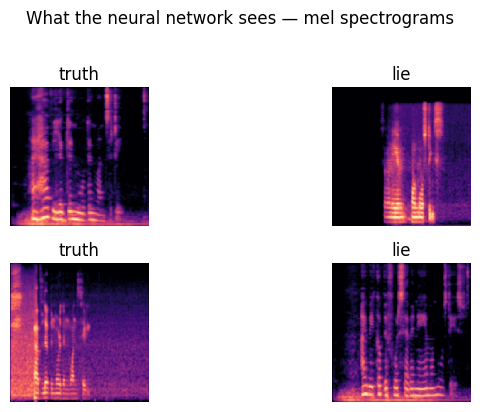

In [6]:
DATA_DIR = Path("../data/dataset_B")

# Fast.ai reads folder names as labels automatically
# data/truth/ → label "truth"
# data/lie/   → label "lie"

dls = ImageDataLoaders.from_folder(
    DATA_DIR,
    valid_pct=0.2,        # 20% held out as validation set — never seen during training
    seed=42,              # same split every run — reproducible
    item_tfms=Resize(224), # resize all spectrograms to 224x224 — ResNet expects this
    bs=4                 # batch size of 4 — small dataset, so small batches to avoid overfitting
)

# Verify it loaded correctly
print(f"Classes: {dls.vocab}")
print(f"Training samples: {len(dls.train_ds)}")
print(f"Validation samples: {len(dls.valid_ds)}")

# Show a batch so you can see what the model will see
dls.show_batch(max_n=6, figsize=(8, 4))
plt.suptitle("What the neural network sees — mel spectrograms", y=1.02)
plt.tight_layout()
plt.show()

In [7]:
# ResNet18 — a proven image classification architecture
# fine_tune() = use pretrained ImageNet weights, then adapt to our data
# This is transfer learning — the model already knows how to read images
# We are teaching it to read spectrograms specifically

learn = vision_learner(dls, resnet18, metrics=error_rate)

print("Starting training — watch the valid_loss column closely")
print("If valid_loss goes UP while train_loss goes DOWN = overfitting\n")

learn.fine_tune(10)  # 10 epochs — enough to see the curve on 22 samples

Starting training — watch the valid_loss column closely
If valid_loss goes UP while train_loss goes DOWN = overfitting



epoch,train_loss,valid_loss,error_rate,time
0,1.281092,0.709184,0.500000,00:01


epoch,train_loss,valid_loss,error_rate,time
0,1.104143,1.462984,0.500000,00:02
1,1.385987,2.355762,0.500000,00:02
2,1.157252,2.843998,0.500000,00:02
3,0.977912,2.024827,0.500000,00:02
4,0.905447,1.848427,0.250000,00:02
5,0.891147,1.910212,0.250000,00:02
6,0.885587,1.872873,0.250000,00:02
7,0.766480,1.481423,0.250000,00:02
8,0.700618,1.365870,0.250000,00:02
9,0.620605,1.247360,0.250000,00:02


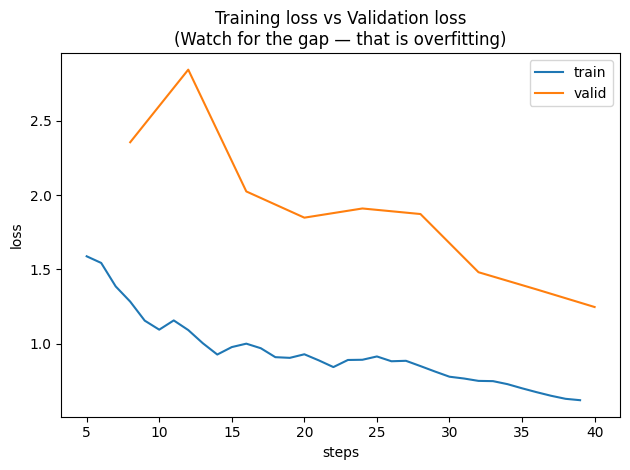

In [8]:
# This is the most important chart you will generate this week
# It shows exactly what you learned about overfitting in Week 1

learn.recorder.plot_loss()
plt.title("Training loss vs Validation loss\n(Watch for the gap — that is overfitting)")
plt.tight_layout()
plt.show()


Final validation error rate: 0.2500
Final validation accuracy: 75.0%


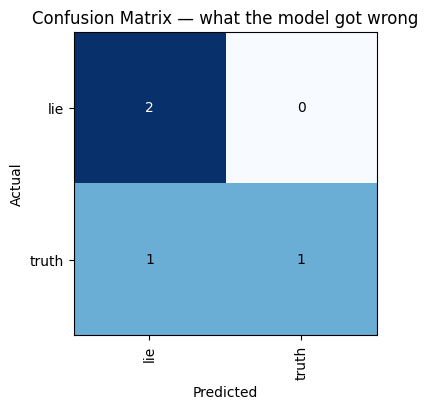

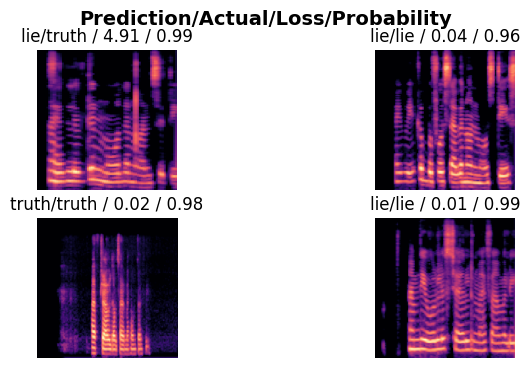

In [11]:
# Get final training and validation metrics
results = learn.validate()
print(f"\nFinal validation error rate: {results[1]:.4f}")
print(f"Final validation accuracy: {(1 - results[1])*100:.1f}%")

# Show what it got wrong
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix(figsize=(4, 4))
plt.title("Confusion Matrix — what the model got wrong")
plt.show()

# Show the highest loss predictions — where the model was most wrong
interp.plot_top_losses(min(4, len(dls.valid_ds)), figsize=(8, 4))
plt.show()